In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("diabetes1.csv")

In [3]:
df.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [4]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [5]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
763    False
764    False
765    False
766    False
767    False
Length: 768, dtype: bool

In [6]:
df.shape

(768, 9)

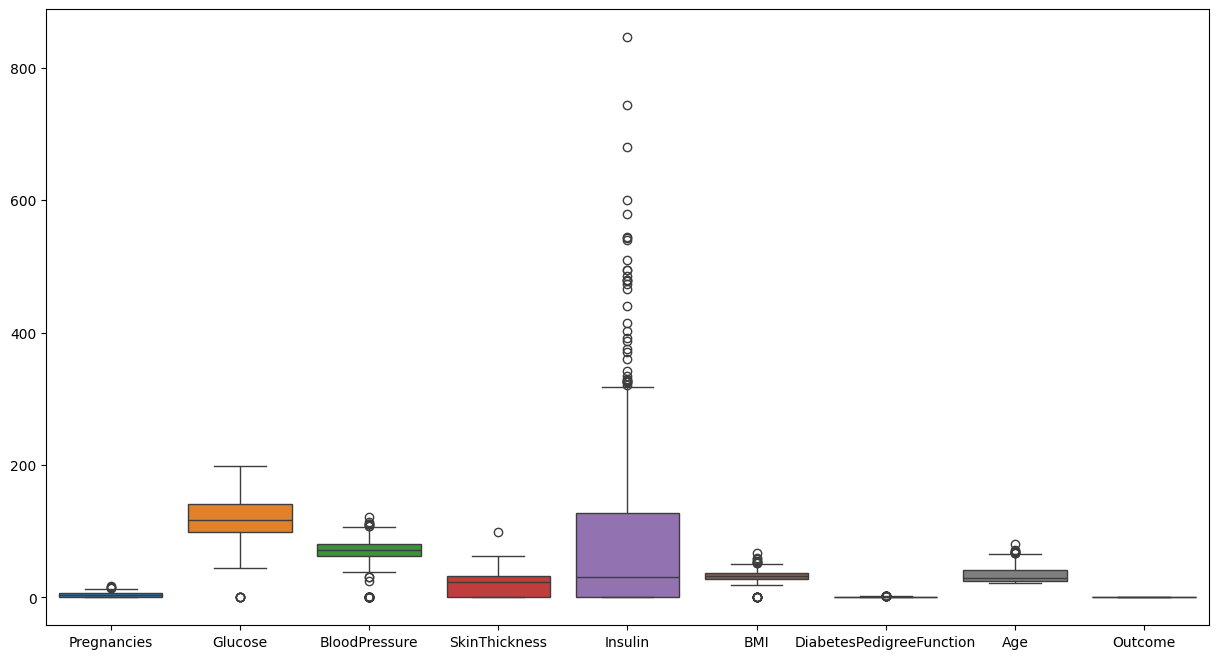

In [7]:

plt.figure(figsize=(15, 8))
sns.boxplot(data=df)
plt.show()

#Every Parameter has got outliers and Insulin has got most outliers 

<Axes: xlabel='Glucose', ylabel='Outcome'>

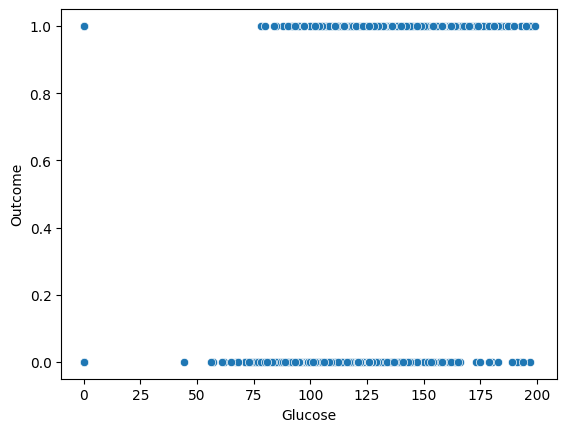

In [8]:
sns.scatterplot(x='Glucose',y='Outcome',data=df)

<Axes: xlabel='BMI', ylabel='Outcome'>

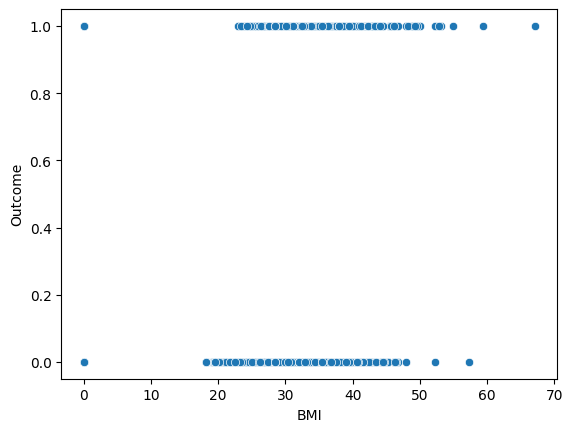

In [9]:
sns.scatterplot(x='BMI',y='Outcome',data=df)

<Axes: xlabel='Insulin', ylabel='Outcome'>

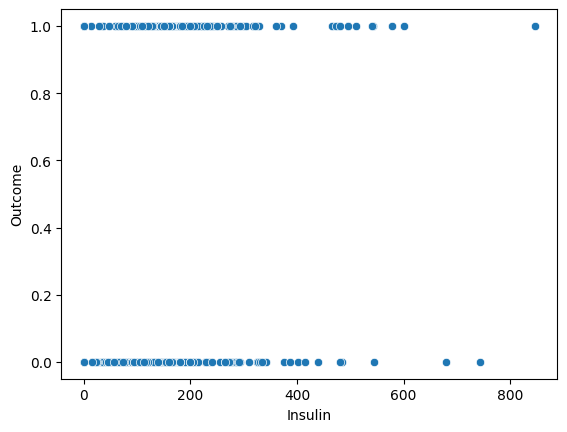

In [10]:
sns.scatterplot(x='Insulin',y='Outcome',data=df)

<Axes: xlabel='BMI', ylabel='Count'>

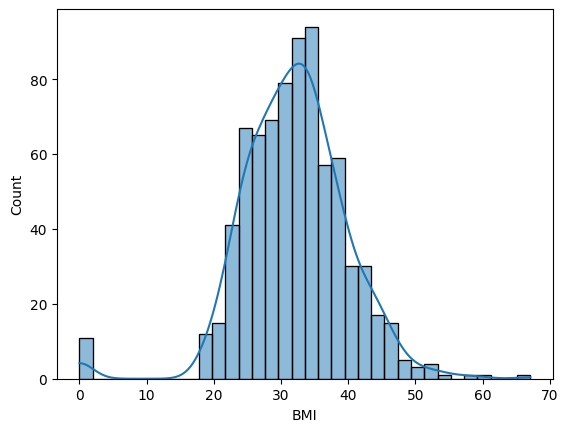

In [11]:
sns.histplot(data=df,x="BMI",kde=True)

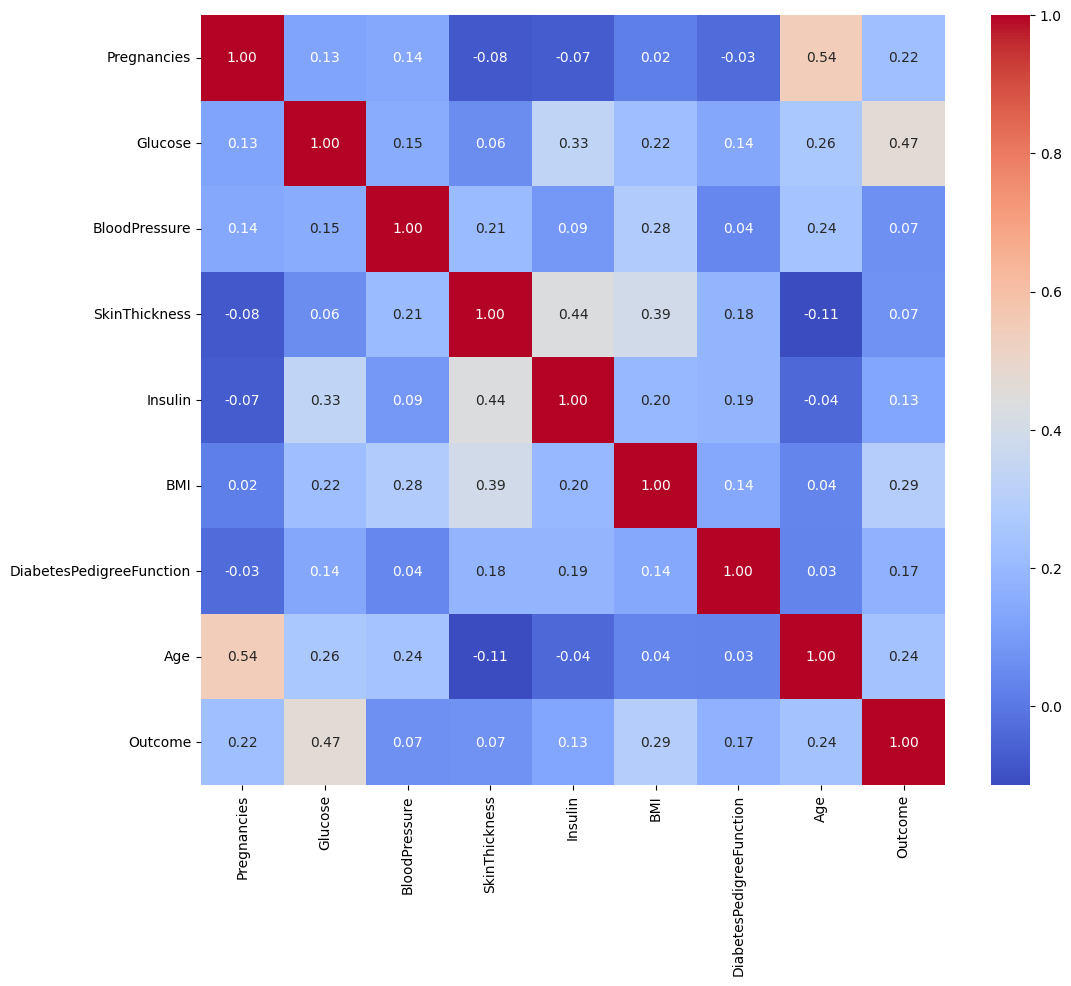

In [12]:
corr_matrix = df.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.show()

Only pregnency and age column has similarity more than 50


In [15]:
Q1 = df['Insulin'].quantile(0.25)
Q3 = df['Insulin'].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

# View the outliers
outliers = df[(df['Insulin'] < lower_limit) | (df['Insulin'] > upper_limit)]
print(outliers.shape[0], "outliers found in Insulin column")


34 outliers found in Insulin column


In [16]:
df['Insulin'] = df['Insulin'].apply(lambda x: upper_limit if x > upper_limit else (lower_limit if x < lower_limit else x))


In [20]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0.0,33.6,0.627,50,1
1,1,85,66,29,0.0,26.6,0.351,31,0
2,8,183,64,0,0.0,23.3,0.672,32,1
3,1,89,66,23,94.0,28.1,0.167,21,0
4,0,137,40,35,168.0,43.1,2.288,33,1


In [21]:
X= df.drop('Outcome', axis=1)
y= df['Outcome']

In [22]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,   test_size=0.2, random_state=42)

In [23]:
from sklearn.linear_model import LogisticRegression

In [24]:
lr= LogisticRegression()
lr.fit(X_train, y_train)

C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [26]:
lr.score(X_test, y_test)

0.7402597402597403

In [27]:
y_pred = lr.predict(X_test)
from sklearn.metrics import confusion_matrix, classification_report

In [28]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[78 21]
 [19 36]]
              precision    recall  f1-score   support

           0       0.80      0.79      0.80        99
           1       0.63      0.65      0.64        55

    accuracy                           0.74       154
   macro avg       0.72      0.72      0.72       154
weighted avg       0.74      0.74      0.74       154



In [35]:
from sklearn.naive_bayes import BernoulliNB

In [40]:
bnb = BernoulliNB()
bnb.fit(X_train, y_train)

BernoulliNB()

In [41]:
y_pred = bnb.predict(X_test)
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score

In [42]:
print(accuracy_score(y_test, y_pred))
print(precision_score(y_test, y_pred))  
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.6558441558441559
0.75
[[98  1]
 [52  3]]
              precision    recall  f1-score   support

           0       0.65      0.99      0.79        99
           1       0.75      0.05      0.10        55

    accuracy                           0.66       154
   macro avg       0.70      0.52      0.44       154
weighted avg       0.69      0.66      0.54       154

